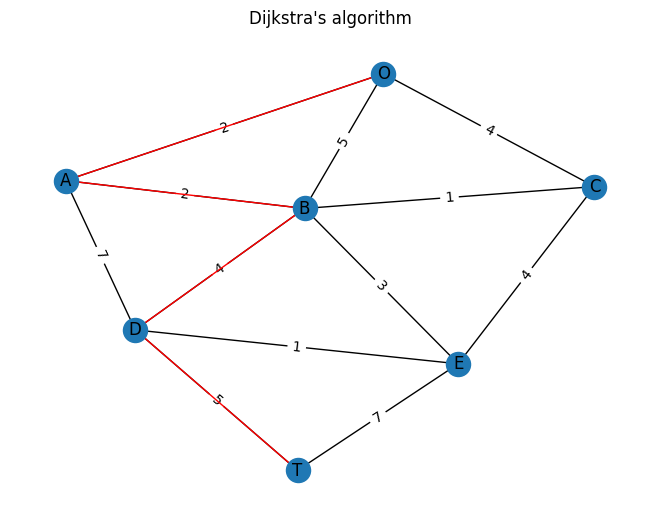

The nodes of the shortest path are: ['O', 'A', 'B', 'D', 'T']
The total lenght of the shortest path is: 13


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Data
## Graph Data given as a dictionary
vdicData = {"O" : [("A", 2), ("B", 5), ["C", 4]],
            "A" : [("O", 2), ("B", 2), ("D", 7)],
            "B" : [("O", 5), ("A", 2), ("C", 1),("D", 4), ("E", 3)],
            "C" : [("O", 4), ("B", 1), ("E", 4)],
            "D" : [("A", 7), ("B", 4), ("E", 1), ("T", 5)],
            "E" : [("B", 3), ("C", 4),("D", 1), ("T",7)],
            "T" : [("D", 5), ("E", 7)]
            }
# Other data
vsGraphTitle = "Dijkstra's algorithm"

# Functions or methods
## Define functions that will be used
def mbImportDataFromDictionary(poGraph, pdicData):
  # This function imports data from a dictionary to a graph.
  lstNodes = list(pdicData.keys())
  for iLoop1 in range(len(lstNodes)):
    sStartingNode = lstNodes[iLoop1]
    lstConectionsNode = pdicData[sStartingNode]
    for iLoop2 in range(len(lstConectionsNode)):
      sEndingNode = lstConectionsNode[iLoop2][0]
      iEdgeWeight = lstConectionsNode[iLoop2][1]
      # Add edge by edge
      poGraph.add_edge(sStartingNode, sEndingNode, weight = iEdgeWeight)

def mlstCreateEdgesFromPath(plstNodesPath):
  # This function creates a list of edges from a list of nodes
  # that creates a path
  lstEdges = []
  for iLoop in range(len(plstNodesPath)):
    if iLoop < len(plstNodesPath) - 1:
      sStartingNode = plstNodesPath[iLoop]
      sEndingNode = plstNodesPath[iLoop + 1]
      lstEdges.append((sStartingNode, sEndingNode))
  return lstEdges

def mbChangeEdgeColor(poGraph, psStartingNode, psEndingNode, psColor="red"):
  # This function changes the color of an edge, default color is red
  poGraph.edges[psStartingNode, psEndingNode]["color"] = psColor

def mbDrawGraph(poGraph, plstPath=[], psTitle = ""):
  # This function draws a graph with tags and colors a path (optional)
  pos = nx.spring_layout(poGraph, seed = 100) # Fix positions of nodes
  nx.draw(poGraph, pos = pos, with_labels = True, )
  # Add tag to each edge
  labels = nx.get_edge_attributes(poGraph,'weight') # get information from graph
  nx.draw_networkx_edge_labels(poGraph, pos, edge_labels=labels)
  if psTitle != "":
    plt.title(psTitle)


  # Color only if path is given
  if len(plstPath) > 0:
    # Apply color
    for iLoop in range(len(plstPath)):
      sEdge = plstPath[iLoop]
      if sEdge in poGraph.edges:
        sElem1 = sEdge[0]
        sElem2 = sEdge[1]
        mbChangeEdgeColor(poGraph, sElem1, sElem2, "red")
      else:
        # edge name in the other direction
        sElem1 = sEdge[0]
        sElem2 = sEdge[1]
        mbChangeEdgeColor(poGraph, sElem2, sElem1, "red")

    colors = nx.get_edge_attributes(poGraph,'color').values()
    for i in range(len(plstPath)):
      nx.draw_networkx_edges(poGraph,pos, edgelist = [plstPath[i]], edge_color=colors)
  plt.show()

# Problem resolution
# Import data
G = nx.Graph() # Define graph
mbImportDataFromDictionary(G, vdicData)

# Dijkstra's algorithm
vsStartingNode = "O"
vsEndingNode = "T"
vlstShortestPath = []
vlstShortestPath = nx.dijkstra_path(G, vsStartingNode,vsEndingNode)

# Show results
vlstEdgesPath = mlstCreateEdgesFromPath(vlstShortestPath)

## Draw graph
mbDrawGraph(G, vlstEdgesPath, vsGraphTitle)
## Nodes of the shortest path
print("The nodes of the shortest path are: "+ str(vlstShortestPath))

## Lenght of the shortest path
viTotalLenght = nx.path_weight(G,vlstShortestPath,'weight')
print("The total lenght of the shortest path is: "+ str(viTotalLenght))